In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

## Liczna epok 
Dla stałej architektury accuracy rośnie szczególnie szybko przy początkowym wzroście liczby epok 1-3 (0.9623->0.9764). W przedziale 4-8 epok zmiany są minimalne, gdzie przy wykorzystaniu dopiero 9 epok model uzyskuje wynik równy 0.98, który przy kolejnych zmianach spada ponizej, osiagając wynik minilanie lepszy dopiero przy 15 epokach. Równocześnie paramter loss w przedziale 5-9 zachowuje się dosyć stabilnie plasując się w wartościach ok. 0.074–0.081. Wyniki te zasugerowały, aby przy kolejnych testach stosować wartość epochs=5 jako optymalną. 

## Liczba warstw ukrytych

Dla treningu accuracy przy 5 epokach wykorzystując konfigurację:
-[128]: 0.9742,
-[128, 64]: 0.9772,
-[128, 64, 32]: 0.9745

Sugeruję to, ze dodanie drugiej warstwy ukrytej przycyznia się tylko do niewielkiej poprawy względem 1 warstwy (róznica około 3 punktów procentówych). Przy zastosowaniu 3 warstwy wynik pogarsza się wracając niemalze do wyniku jaki został uzyskany przy 1 warstwie. 

## Ocena konkretnych liczb

Cyfra 0: accuracy = 0.9908 (poprawne 971/980)
Cyfra 1: accuracy = 0.9921 (poprawne 1126/1135)
Cyfra 2: accuracy = 0.9767 (poprawne 1008/1032)
Cyfra 3: accuracy = 0.9802 (poprawne 990/1010)
Cyfra 4: accuracy = 0.9786 (poprawne 961/982)
Cyfra 5: accuracy = 0.9608 (poprawne 857/892)
Cyfra 6: accuracy = 0.9823 (poprawne 941/958)
Cyfra 7: accuracy = 0.9718 (poprawne 999/1028)
Cyfra 8: accuracy = 0.9825 (poprawne 957/974)
Cyfra 9: accuracy = 0.9683 (poprawne 977/1009)

Najlepiej wypadły liczby 0 oraz 1. Moze to wynikac z prostoty ich zapisania i uknialności. Najgorzej wypadły cyfry 5,7 oraz 9. Niechlujnie zapisane 5 moze przypominać 3, 7 ->1, a nierówne 9 mogłoby wpadać w klasyfikacje 0 lub 4. 

# Trudności w trakcie realizacji

Początkowa implementacja pętli dla testów epok została przeze mnie źle zaimplementowana. W rezultacie kazdy kolejny jej obieg trenował ponownie ten sam juz wytrenowany model, co w końcu dało model nauczony na ponad 100 epokach oraz wyniki, które były dosyć statyczne. Próba poprawy stanu rzeczy doprowadziła do kodu, który jest przedstawiony ponizej.

Następnie uznałem za bezsensowne pisanie wielokrtonie kodu do tworzenia nowych modeli. W tym celu napisałem metodę build_model(), aby usprawnić proces i aby sam kod był bardziej schludny. 

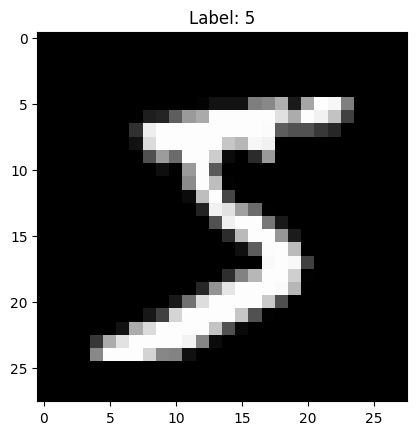

In [15]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

plt.imshow(x_train[0], cmap='gray')
plt.title("Label: " + str(y_train[0]))
plt.show()

In [16]:
def build_model(hidden_layers):
    model = tf.keras.models.Sequential()
    model.add(tf.keras.Input(shape=(28, 28)))
    model.add(tf.keras.layers.Flatten())

    for neurons in hidden_layers:
        model.add(tf.keras.layers.Dense(neurons, activation='relu'))

    model.add(tf.keras.layers.Dense(10, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [22]:
epoch_results = []

for epochs in range(1, 16):
    tf.keras.backend.clear_session()
    model = build_model([128])
    model.fit(x_train, y_train, epochs=epochs, verbose=0)
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=1)
    epoch_results.append((epochs, test_acc, test_loss))
    print(f"Epochs: {epochs}, Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")
    

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 512us/step - accuracy: 0.9623 - loss: 0.1298
Epochs: 1, Test Accuracy: 0.9623, Test Loss: 0.1298
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 534us/step - accuracy: 0.9646 - loss: 0.1105
Epochs: 2, Test Accuracy: 0.9646, Test Loss: 0.1105
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step - accuracy: 0.9764 - loss: 0.0794
Epochs: 3, Test Accuracy: 0.9764, Test Loss: 0.0794
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 503us/step - accuracy: 0.9763 - loss: 0.0807
Epochs: 4, Test Accuracy: 0.9763, Test Loss: 0.0807
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step - accuracy: 0.9775 - loss: 0.0758
Epochs: 5, Test Accuracy: 0.9775, Test Loss: 0.0758
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 503us/step - accuracy: 0.9777 - loss: 0.0750
Epochs: 6, Test Accuracy: 0.9777, Test Loss: 0.0750
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step - accuracy: 0.9758 - loss: 0.0806
Epochs: 7, Test Accuracy: 0.9758, Test Loss: 0.0806
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 503us/step - accuracy: 0.9798 - loss: 0.0740
Epochs: 8, Test Accu

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 416us/step
[2.6159942e-13 2.1320416e-15 4.5518603e-10 4.0299224e-08 8.8000873e-17
 1.7541762e-13 2.1916881e-22 1.0000000e+00 8.0446505e-10 3.6432393e-08]


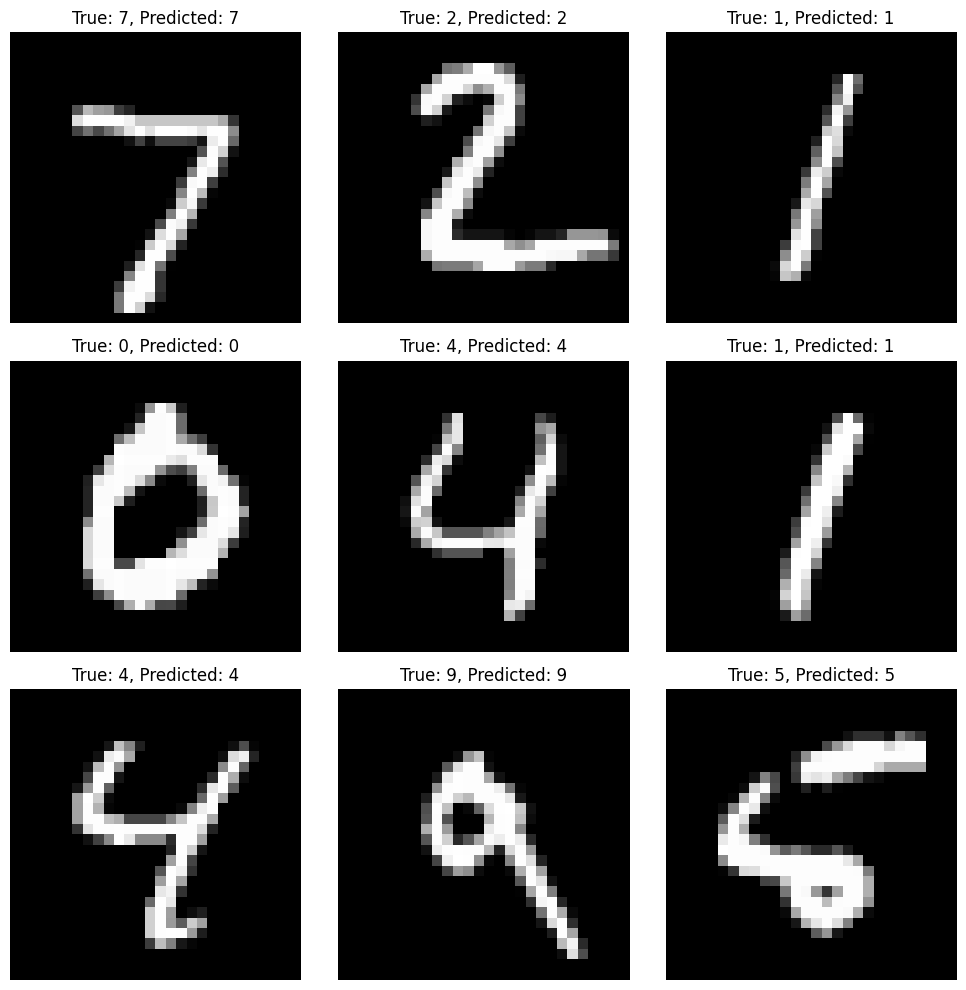

In [13]:
predictions = model.predict(x_test)
print(predictions[0])
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"True: {y_test[i]}, Predicted: {tf.argmax(predictions[i])}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [24]:
#test dodania kolejnej warstwy ukrytej do modelu
layer_results = []
layer_configs = [[128], [128, 64], [128, 64, 32]]
for config in layer_configs:
    tf.keras.backend.clear_session()
    model = build_model(config)
    model.fit(x_train, y_train, epochs=5, verbose=1)
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=1)
    layer_results.append((config, test_acc, test_loss))
    print(f"Layer Config: {config}, Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 770us/step - accuracy: 0.9262 - loss: 0.2598
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 765us/step - accuracy: 0.9658 - loss: 0.1141
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 764us/step - accuracy: 0.9756 - loss: 0.0790
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 769us/step - accuracy: 0.9822 - loss: 0.0587
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 767us/step - accuracy: 0.9863 - loss: 0.0444
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 507us/step - accuracy: 0.9742 - loss: 0.0831
Layer Config: [128], Test Accuracy: 0.9742, Test Loss: 0.0831
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 809us/step - accuracy: 0.9292 - loss: 0.2392
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 820us/step - accuracy: 0.9698 - loss: 0.0994
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 804us/step - accuracy: 0.9782 - loss: 0.0706
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 805us/step - accuracy: 0.9825 - loss: 0.0531
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 804us/step - acc

In [26]:
#test zmiany liczby neuronów w warstwie ukrytej
neuron_results = []
neuron_configs = [[64], [128], [256]]
for neurons in neuron_configs:
    tf.keras.backend.clear_session()
    model = build_model(neurons)
    model.fit(x_train, y_train, epochs=5, verbose=1)
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=1)
    neuron_results.append((neurons, test_acc, test_loss))
    print(f"Neurons: {neurons}, Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 623us/step - accuracy: 0.9163 - loss: 0.2986
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 873us/step - accuracy: 0.9579 - loss: 0.1430
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 588us/step - accuracy: 0.9692 - loss: 0.1054
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 681us/step - accuracy: 0.9749 - loss: 0.0826
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 723us/step - accuracy: 0.9789 - loss: 0.0682
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 518us/step - accuracy: 0.9737 - loss: 0.0872
Neurons: [64], Test Accuracy: 0.9737, Test Loss: 0.0872
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9269 - loss: 0.2588
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 836us/step - accuracy: 0.9648 - loss: 0.1172
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 812us/step - accuracy: 0.9754 - loss: 0.0799
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 862us/step - accuracy: 0.9819 - loss: 0.0601
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 865us/step - accuracy: 0

In [ ]:

# Predykcje klas (0–9) zamiast wektorów softmax
y_pred = np.argmax(predictions, axis=1)

num_classes = 10
class_accuracies = []

for digit in range(num_classes):
    idx = (y_test == digit)
    correct = np.sum(y_pred[idx] == y_test[idx])
    total = np.sum(idx)
    acc = correct / total if total > 0 else 0.0
    class_accuracies.append(acc)
    print(f"Cyfra {digit}: accuracy = {acc:.4f} (poprawne {correct}/{total})")

Cyfra 0: accuracy = 0.9908 (poprawne 971/980)
Cyfra 1: accuracy = 0.9921 (poprawne 1126/1135)
Cyfra 2: accuracy = 0.9767 (poprawne 1008/1032)
Cyfra 3: accuracy = 0.9802 (poprawne 990/1010)
Cyfra 4: accuracy = 0.9786 (poprawne 961/982)
Cyfra 5: accuracy = 0.9608 (poprawne 857/892)
Cyfra 6: accuracy = 0.9823 (poprawne 941/958)
Cyfra 7: accuracy = 0.9718 (poprawne 999/1028)
Cyfra 8: accuracy = 0.9825 (poprawne 957/974)
Cyfra 9: accuracy = 0.9683 (poprawne 977/1009)
